In [11]:
#simulation od binomial distribution of titanic datase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom

In [6]:
df = pd.read_csv('titanic.csv')
df.columns

Index(['survived', 'pclass', 'gender', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'deck'],
      dtype='object')

In [14]:
n_survived = len(df[df['survived'] == 1])
n_total = len(df)
p_survived = n_survived/n_total
print(p_survived)

0.3838383838383838


In [15]:
#simulate 100 hypothetical oassengers
trials = 100
x = np.arange(0, trials+1)

#pmf and cdf
pmf_values = binom.pmf(x, trials, p_survived)
cdf_values = binom.cdf(x, trials, p_survived)


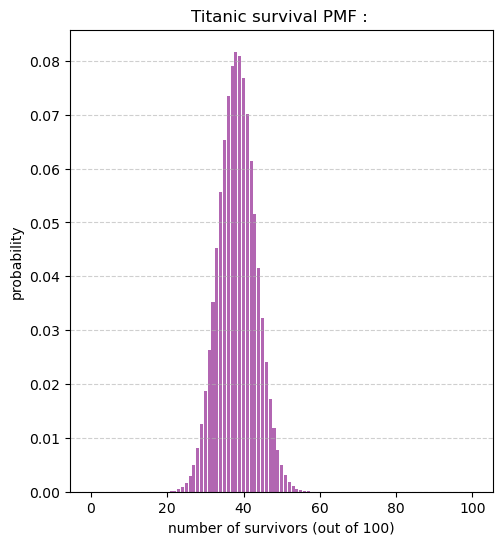

In [16]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.bar(x, pmf_values, color = 'purple', alpha =0.6)
plt.title("Titanic survival PMF : ")
plt.xlabel("number of survivors (out of 100)")
plt.ylabel("probability")
plt.grid(axis = 'y', linestyle = "--",alpha = 0.6)


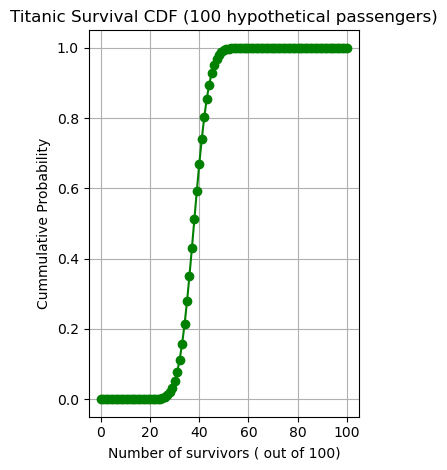

In [17]:
plt.subplot(1,2,2)
plt.plot(x, cdf_values, color ="green", marker = 'o', linestyle = '-')
plt.title("Titanic Survival CDF (100 hypothetical passengers)")
plt.xlabel("Number of survivors ( out of 100)")
plt.ylabel("Cummulative Probability")
plt.grid()
plt.tight_layout()
plt.show()

In [19]:
#Assignment - combine datasets : 
df_20 = pd.read_csv("century20.csv")
df_21 = pd.read_csv("century21.csv")
print("Century 20 : ", "\n", df_20.head(2))
print("Century 21 : ", "\n", df_21.head(2))
                    

Century 20 :  
   Result     Margin                Match Home/Away      Ground  Match Date  \
0   Lost  5 wickets  Australia v England      Away   Melbourne  1971/01/05   
1    Won  6 wickets  England v Australia      Home  Manchester  1972/08/24   

  Match Month  Match Year Match Period  Matches  Country  
0         Jan        1971     Jan 1971        1  England  
1         Aug        1972     Aug 1972        1  England  
Century 21 :  
   Result     Margin                Match Home/Away         Ground  Match Date  \
0   Lost  5 wickets  Sri Lanka v England      Away       Dambulla  2001/03/23   
1   Lost    66 runs  Sri Lanka v England      Away  Colombo (RPS)  2001/03/25   

  Match Month  Match Year Match Period  Matches  Country  
0         Mar        2001     Mar 2001        1  England  
1         Mar        2001     Mar 2001        1  England  


In [20]:
df1 = pd.concat([df_20, df_21])
df1.head(2)

,Result,Margin,Match,Home/Away,Ground,Match Date,Match Month,Match Year,Match Period,Matches,Country
0,Lost,5 wickets,Australia v England,Away,Melbourne,1971/01/05,Jan,1971,Jan 1971,1,England
1,Won,6 wickets,England v Australia,Home,Manchester,1972/08/24,Aug,1972,Aug 1972,1,England


In [37]:
total_match = len(df1[(df1['Country'] == "India") & (df1['Result'].isin(["Won", "Lost","Tied"]))])
won_match = len(df1[(df1['Country'] == "India") & (df1['Result'] == "Won")])
win_rate = won_match/total_match
loss_rate = 1 - win_rate
print(win_rate)
#a)What is the probability that india win exactly 35 out of these 60 matches ?
n =60
p_a = binom.pmf(35, n, win_rate)
print("Probability of india win exactly 35 out of these 60 matches :", p_a)

#b)What is the probability that india will win more than 40 matches ?
p_b = binom.cdf(60,60,win_rate) - binom.cdf(40,60,win_rate)
print("Probability that India will win more than 40 matches : ", p_b)

#c)What is the probability that india wins at least 45 matches?
p_c = binom.pmf(45,60,win_rate)
print("probability that india wins at least 45 matches : ", p_c)

#d)What is the most likely number of wins India will have in 60 matches?
matches = pd.Series(np.arange(0, n+1))
pmf_values = matches.apply(lambda x: binom.pmf(x, n, win_rate))
most_likely_wins = matches.iloc[pmf_values.idxmax()]  # now works
print("Most likely number of wins:", most_likely_wins)

0.5422832980972516
Probability of india win exactly 35 out of these 60 matches : 0.08474879381709416
Probability that India will win more than 40 matches :  0.01850513244523444
probability that india wins at least 45 matches :  0.00047314588613136735
Most likely number of wins: 33


In [6]:
#Question 4. 
#Calculate Z-score and do outlier analysis on (a) Glucose column of Diabetes dataset, (b) Billionaries dataset
from scipy.stats import zscore
df1 = pd.read_csv('diabetes.csv')
print(df1.columns)
df1.head(2)

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0


In [37]:
print('Part - a : Glucose column')
g_mean = df1['Glucose'].mean()
g_std = df1['Glucose'].std()
df1['glucose_zscore'] = zscore(df1['Glucose'])
threshold = 3
glucose_outliers = df1[df1['glucose_zscore'].abs() > threshold]

print(glucose_outliers['glucose_zscore'].drop_duplicates())

Part - a : Glucose column
75   -3.783654
Name: glucose_zscore, dtype: float64


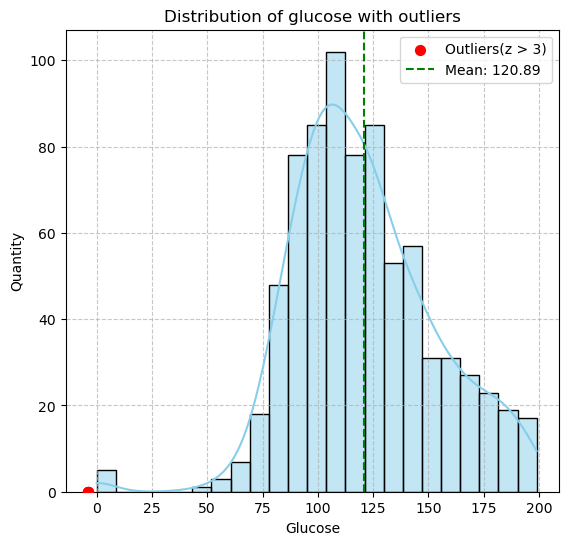

In [16]:
plt.figure(figsize =(14,6))
#plot for glucose outliers
plt.subplot(1,2,1)
sns.histplot(df1['Glucose'], kde = True, color ='skyblue')
plt.scatter(glucose_outliers['glucose_zscore'], [0]*len(glucose_outliers), color = 'red', s = 50, zorder = 5, label = f'Outliers(z > {threshold})')
plt.axvline(g_mean, color='green', linestyle = '--', label = f'Mean: {g_mean:.2f}')
plt.title('Distribution of glucose with outliers')
plt.xlabel('Glucose')
plt.ylabel('Quantity')
plt.legend()
plt.grid(True, linestyle = '--', alpha = 0.7)

In [18]:
#b) 
df2= pd.read_csv('billionaires.csv')
df2.head()

,rank,finalWorth,category,personName,age,country,city,source,industries,countryOfCitizenship,...,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,latitude_country,longitude_country
0,1,211000,Fashion & Retail,Bernard Arnault & family,74.0,France,Paris,LVMH,Fashion & Retail,France,...,1.1,"$2,715,518,274,227",65.6,102.5,82.5,24.2,60.7,67059887.0,46.227638,2.213749
1,2,180000,Automotive,Elon Musk,51.0,United States,Austin,"Tesla, SpaceX",Automotive,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
2,3,114000,Technology,Jeff Bezos,59.0,United States,Medina,Amazon,Technology,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
3,4,107000,Technology,Larry Ellison,78.0,United States,Lanai,Oracle,Technology,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
4,5,106000,Finance & Investments,Warren Buffett,92.0,United States,Omaha,Berkshire Hathaway,Finance & Investments,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891


In [21]:
finalworth_mean = df2['finalWorth'].mean()
finalworth_std = df2['finalWorth'].std()
df2['finalworth_zscore'] = zscore(df2['finalWorth'])

print(f"Mean ={finalworth_mean:.2f}")
print(f"Standard Deviation ={finalworth_std:.2f}")
zscore_threshold = 3

Mean =4623.79
Standard Deviation =9834.24


In [38]:
finalworth_outliers = df2[(df2['finalworth_zscore'].abs() > zscore_threshold)].drop_duplicates()
print(f"Total outliers : {len(finalworth_outliers)}")

Total outliers : 37


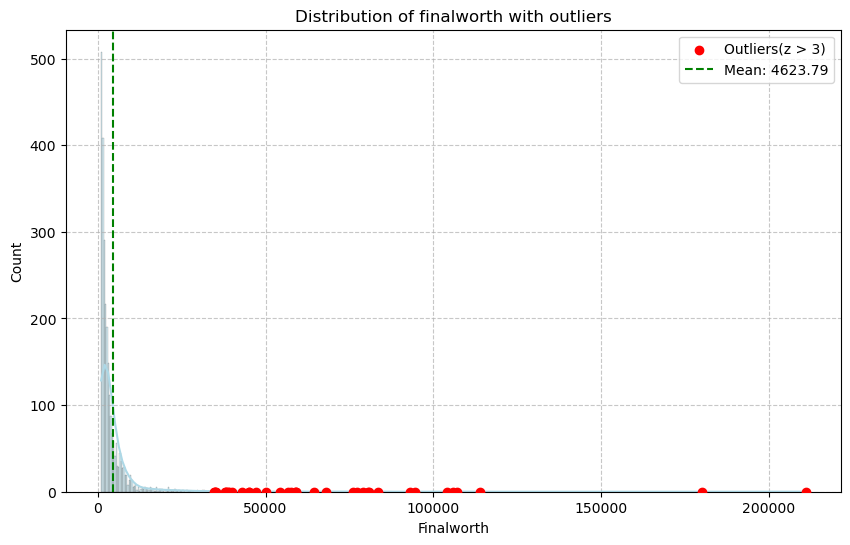

In [40]:
#plot for finalworth outliers
plt.figure(figsize =(10,6))
sns.histplot(df2['finalWorth'], kde = True, color ='lightblue')
plt.scatter(finalworth_outliers['finalWorth'], [0]*len(finalworth_outliers), color = 'red', zorder = 5, label = f'Outliers(z > {zscore_threshold})')
plt.axvline(finalworth_mean, color='green', linestyle = '--', label = f'Mean: {finalworth_mean:.2f}')
plt.title('Distribution of finalworth with outliers')
plt.xlabel('Finalworth')
plt.legend()
plt.grid(True, linestyle = '--', alpha = 0.7)